**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

**Load dataset using Pandas library**

In [2]:
data = pd.read_csv('/content/advertising.csv')
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


**Analyzing shape**

In [3]:
data.shape

(200, 4)

**Data Cleaning - Checking Missing value**

In [4]:
data.isnull().sum()


,0
TV,0
Radio,0
Newspaper,0
Sales,0


**Visualizing Dependent variable 'sales' with all independent variable (features)**

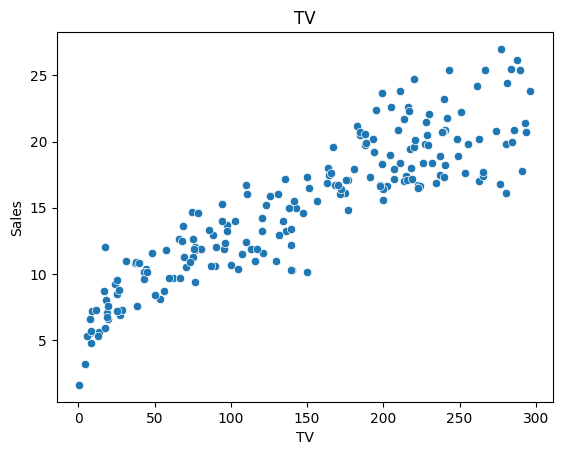

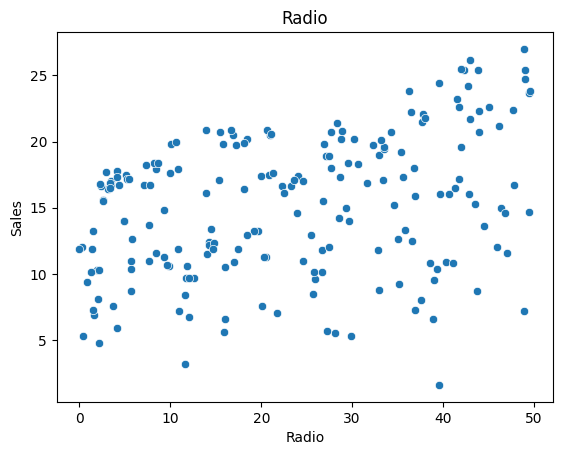

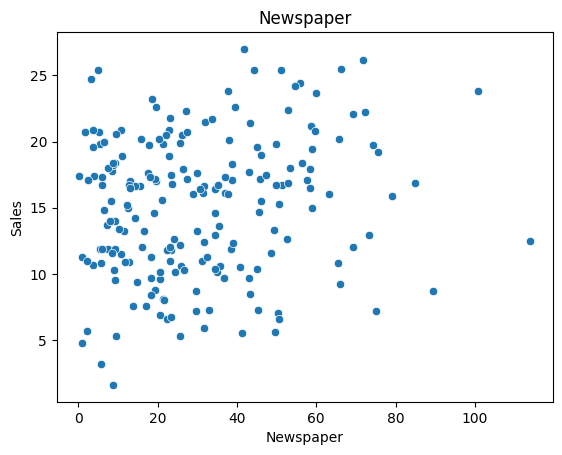

In [5]:
# Distribution of data points

for column_name in data.columns:
    if column_name != 'Sales':
        sns.scatterplot(data=data,x=column_name,y='Sales')
        plt.title(column_name)
        plt.show()

**Checking correlation values with Target variable**

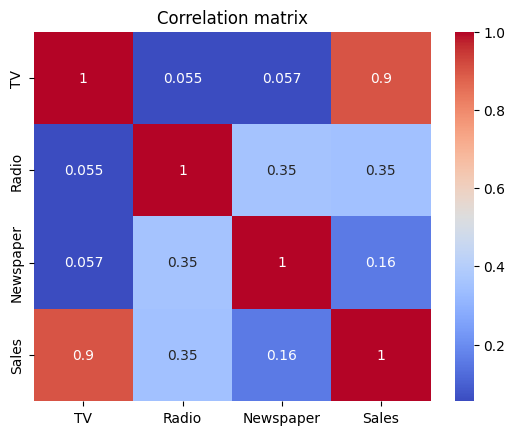

In [6]:
# Heat of Correlations
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

**Plotting data**

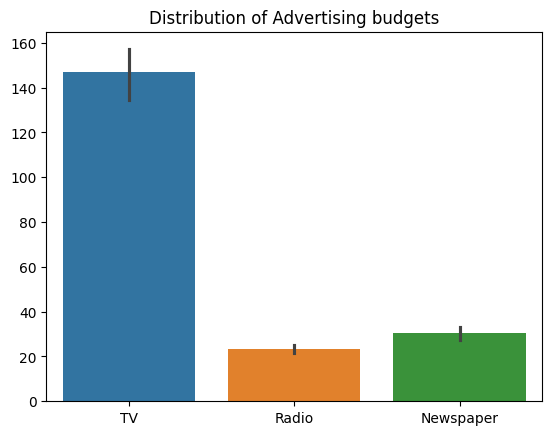

In [7]:
# box plots
sns.barplot(data=data[['TV','Radio','Newspaper']])
plt.title('Distribution of Advertising budgets')
plt.show()

**Splitting Data into Training and Testing**

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
x = data[['TV','Radio','Newspaper']]
y = data['Sales']

# Split the data
x_train,x_test, y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=0)

**Linear Regression**



For more information:
https://scikit-learn.org/dev/modules/generated/sklearn.linear_model.LinearRegression.html

In [9]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

**Passing regression line with data points**

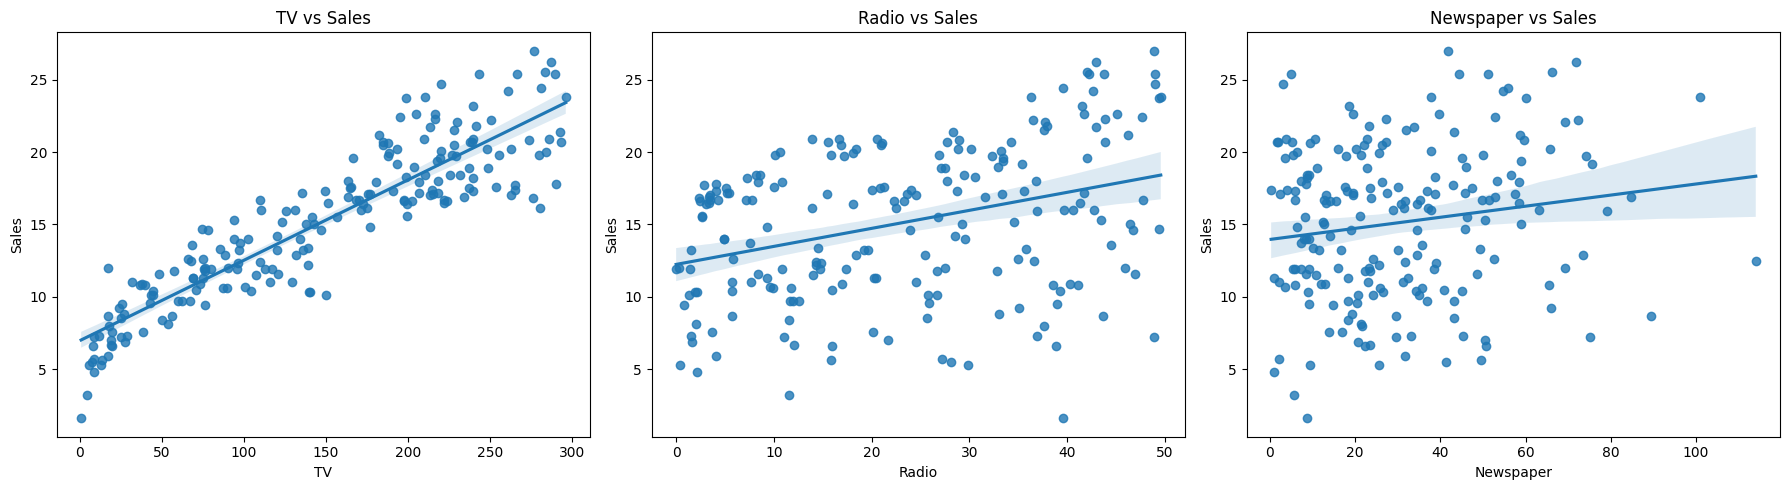

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TV
sns.regplot(x='TV', y='Sales', data=data, ax=axes[0])
axes[0].set_title('TV vs Sales')

# Sales
sns.regplot(x='Radio', y='Sales', data=data, ax=axes[1])
axes[1].set_title('Radio vs Sales')

# Newspaper
sns.regplot(x='Newspaper', y='Sales', data=data, ax=axes[2])
axes[2].set_title('Newspaper vs Sales')

plt.tight_layout()
plt.show()

**Testing on data**

In [11]:
y_pred = model.predict(x_test)

**Evaluating Regression model using R - Squared Measure and Mean Squared Error**

In [12]:
from sklearn.metrics import mean_squared_error ,r2_score
r2 = r2_score(y_test,y_pred)
r2

0.8645053923967724

In [13]:
mse = mean_squared_error(y_test,y_pred)
mse

4.522552562041291

**Root Mean Squared Error**

It is just root value of 'Mean Squared Error'

In [14]:
rmse = np.sqrt(mse)
rmse

2.1266293899128947

**Mean Absolute Error**

In [15]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
mae


1.417031303060067

**Mean Absolute Percentage Error**

In [16]:
from sklearn.metrics import mean_absolute_percentage_error

error= mean_absolute_percentage_error(y_test,y_pred)
print(f'Accuracy of Linear Regression is %.2f'%((1-error)*100))

Accuracy of Linear Regression is 79.29


**Real Time Testing in Regression**

In [18]:
model.predict([[230.1,37.8,69.2]])
#remember we need to pass value in [] and inside [] pass value in [] also.

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([21.09767063])

In [19]:
model.predict([[230.1,37.8,69.2],[130.1,39.8,25.2]])
# for multiple values, values should be separated by ,(comma)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([21.09767063, 16.1072307 ])

In [20]:
model.predict(np.array([100,100,200]).reshape(1,3))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([20.59150203])

**If Transformation is applied then**

In [20]:
from sklearn.preprocessing import StandardScaler
model.predict(StandardScaler.transform([[230.1,37.8,69.2]]))

**SVR (Support Vector Regressor)**

Important parameter:
1. kernel


For more information:
https://scikit-learn.org/dev/modules/generated/sklearn.svm.SVR.html

In [21]:
from sklearn.svm import SVR
svr_model = SVR()
svr_model.fit(x_train,y_train)

SVR()

In [22]:
y_pred_svr = svr_model.predict(x_test)
y_pred_svr

array([10.83197701,  9.43199023, 11.13620288, 21.27532831, 15.8142656 ,
        9.53316961, 10.07076148, 18.54588596,  9.74879265, 17.98511076,
       21.18817568, 11.46620759, 14.73731315, 17.36546637, 11.55549349,
       13.77717611, 19.69023632,  8.73798747, 12.79768711, 18.71506103,
       21.11885304, 13.88523437, 16.97798976, 14.41789947,  9.27676809,
       14.79774769, 15.64789174, 19.58580074, 17.76590456,  8.96426241,
       13.11099825, 19.65367591, 20.02280998, 20.49602282,  8.34439983,
        8.16127244, 10.04607181, 16.61452963, 12.059168  ,  8.34429743])

In [23]:
from sklearn.metrics import mean_squared_error ,r2_score
r2 = r2_score(y_test,y_pred_svr)
r2

0.8338438785576546

In [24]:
mse = mean_squared_error(y_test,y_pred_svr)
mse

5.545975637114748

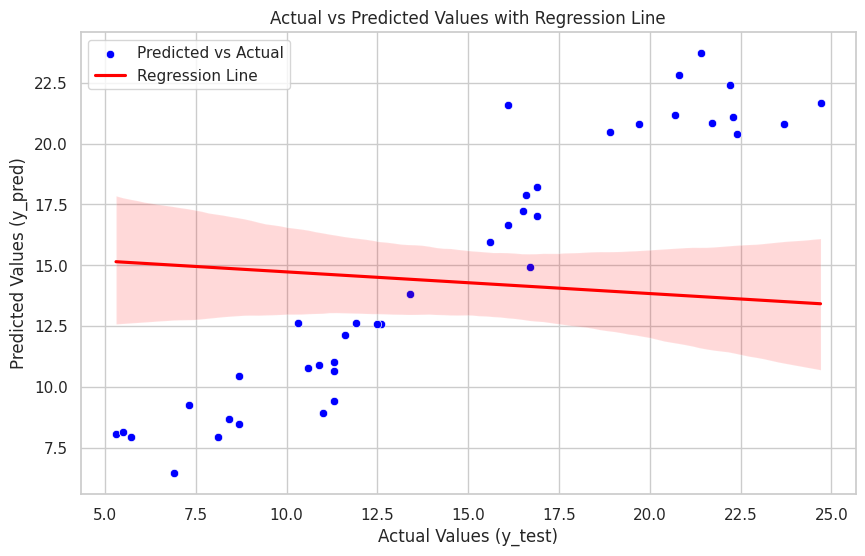

In [61]:
# Create a scatter plot for actual vs predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', label='Predicted vs Actual')

# Plot the regression line (using a simple linear fit)
sns.regplot(x=y_test, y=y_pred_svr, scatter=False, color='red', label='Regression Line')

# Add labels and title
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs Predicted Values with Regression Line')
plt.legend()

# Show plot
plt.show()


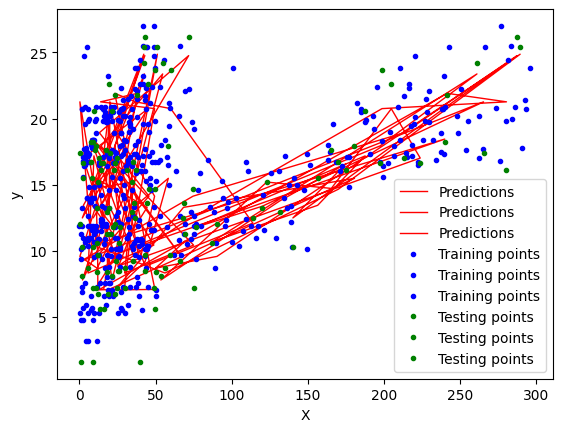

In [25]:
plt.plot(x_test, y_pred, "r-", linewidth=1, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

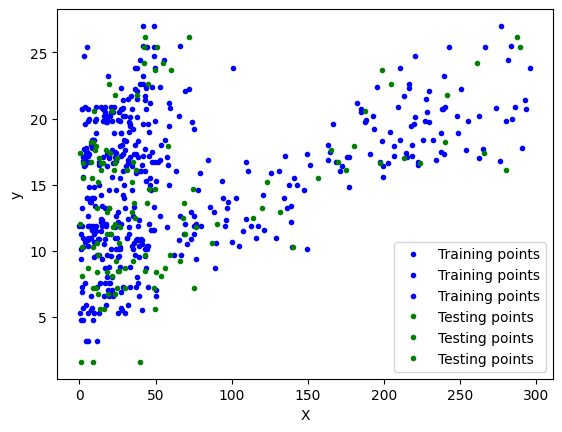

In [26]:
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

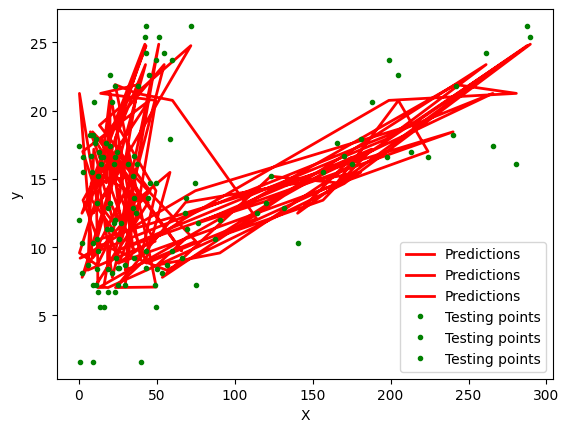

In [27]:
plt.plot(x_test, y_pred, "r-", linewidth=2, label="Predictions")
#plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

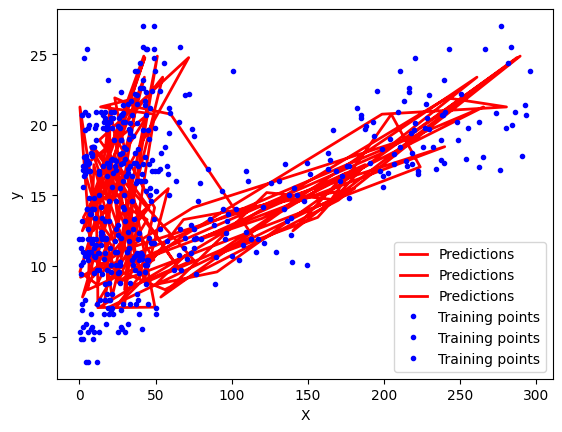

In [28]:
plt.plot(x_test, y_pred, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
#plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

**Polynomial Features**

In [29]:
# Fitting Polynomial Regression to the dataset
from sklearn.preprocessing import PolynomialFeatures
x_train,x_test, y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=0)
#applying polynomial regression degree 2
poly = PolynomialFeatures(degree=2, include_bias=True)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)
#include bias parameter
lr2 = LinearRegression()
lr2.fit(x_train_trans, y_train)
y_pred_2 = lr2.predict(x_test_trans)
print(r2_score(y_test, y_pred_2))


0.9185176895823228


**Viewing Coefficents and Intercept Linear Regression**

In [30]:
print(lr2.coef_)
print(lr2.intercept_)

[ 0.00000000e+00  7.31730645e-02 -2.00377613e-02 -2.04227869e-02
 -9.42391008e-05  3.32459534e-04 -5.37895431e-06  1.68230306e-03
  1.12288210e-04  1.98777943e-04]
5.42850900258213


**Changing Degree Value (Power) to note down updation in output**

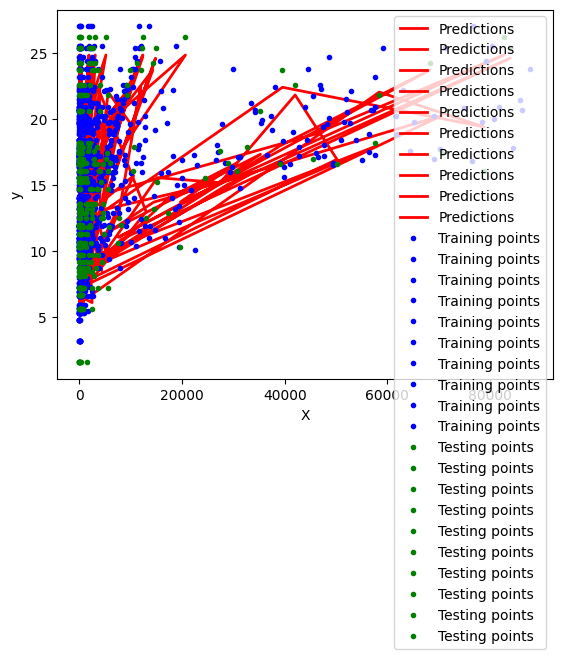

In [31]:

#X_new_poly = poly.transform(x_test)
#y_new = lr2.predict(X_new_poly)
#plt.plot(X_new_poly, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_test_trans, y_pred_2, "r-", linewidth=2, label="Predictions")
plt.plot(x_train_trans, y_train, "b.",label='Training points')
plt.plot(x_test_trans, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

**Visualizing Acutual Value ( Test Data ) and Predicted Data( y_pred)**

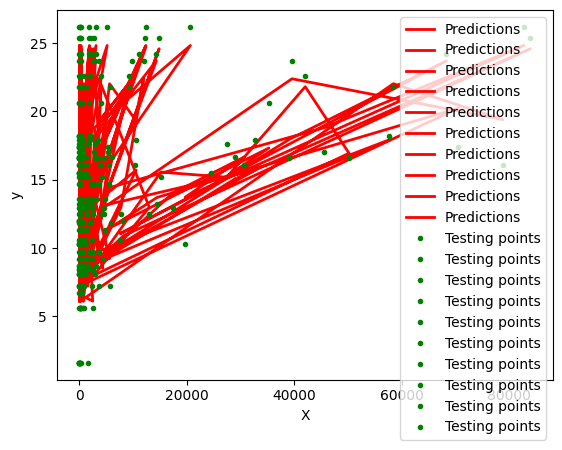

In [32]:
plt.plot(x_test_trans, y_pred_2, "r-", linewidth=2, label="Predictions")
#plt.plot(x_train_trans, y_train, "b.",label='Training points')
plt.plot(x_test_trans, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [33]:
# Fitting Polynomial Regression to the dataset
from sklearn.preprocessing import PolynomialFeatures
x_train,x_test, y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=0)
#applying polynomial regression degree 2
poly_3 = PolynomialFeatures(degree=3, include_bias=True)
x_train_trans_3 = poly_3.fit_transform(x_train)
x_test_trans_3 = poly_3.transform(x_test)
#include bias parameter
lr3 = LinearRegression()
lr3.fit(x_train_trans_3, y_train)
y_pred_3 = lr3.predict(x_test_trans_3)
print(r2_score(y_test, y_pred_3))

0.9148239081591374


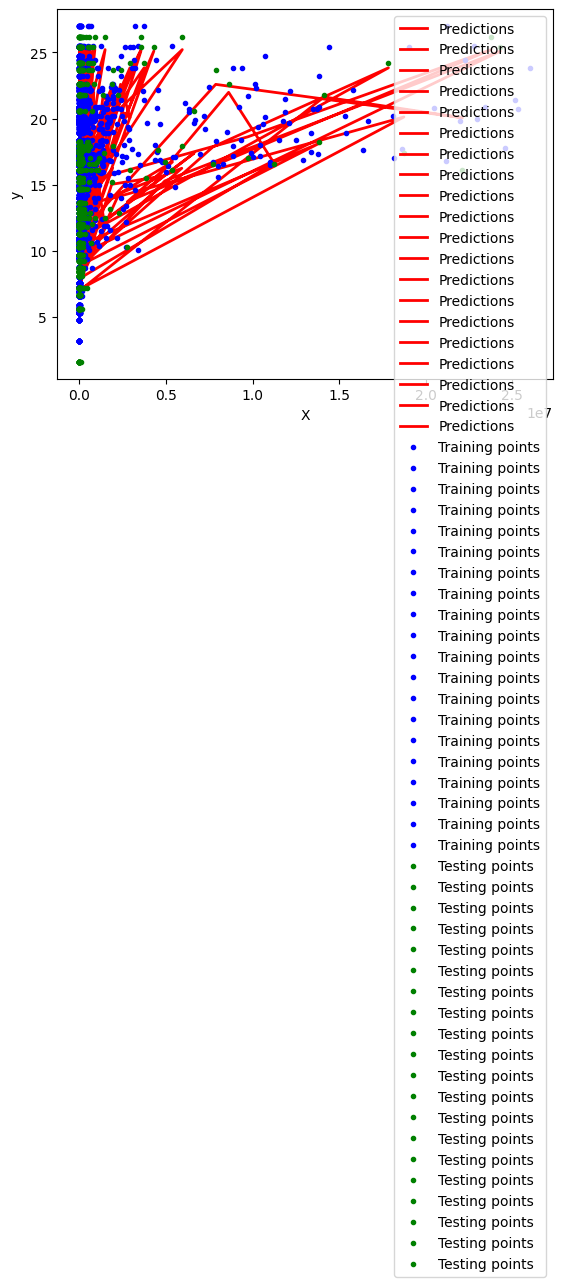

In [34]:
plt.plot(x_test_trans_3, y_pred_3, "r-", linewidth=2, label="Predictions")
plt.plot(x_train_trans_3, y_train, "b.",label='Training points')
plt.plot(x_test_trans_3, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

**Decision Tree Regressor**


For More information:
https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeRegressor.html

In [35]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor()
dt_model.fit(x_train,y_train)

DecisionTreeRegressor()

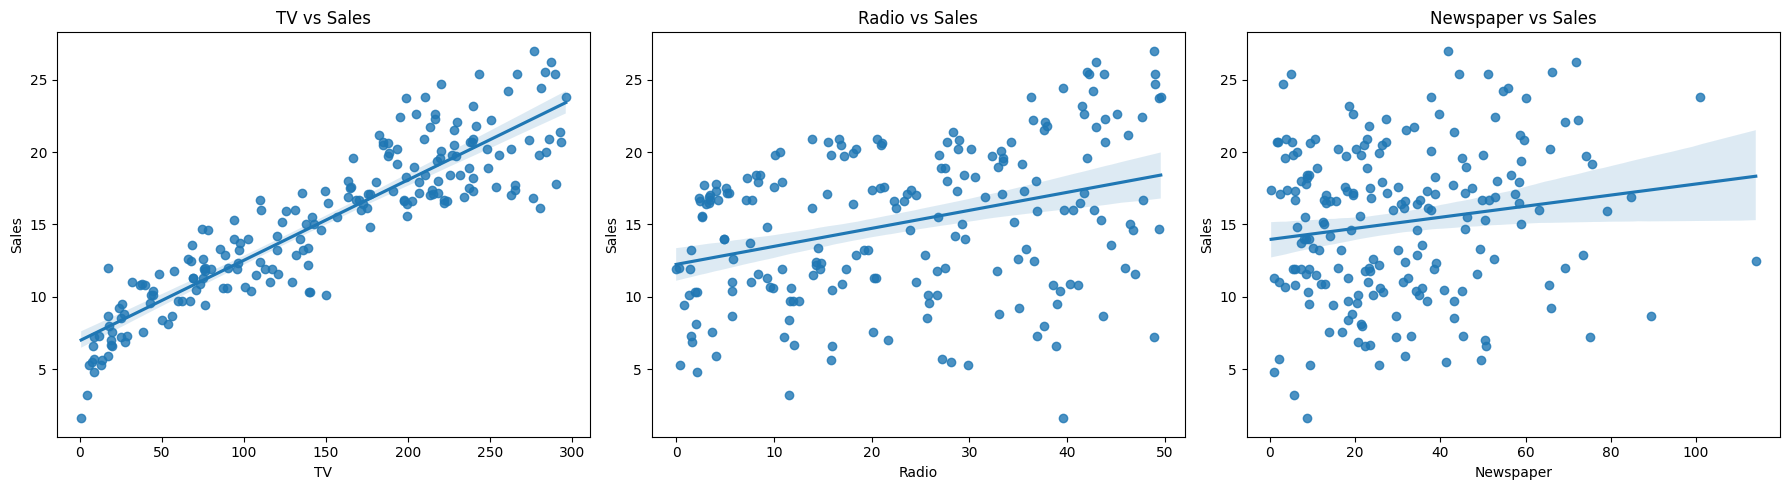

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TV
sns.regplot(x='TV', y='Sales', data=data, ax=axes[0])
axes[0].set_title('TV vs Sales')

# Sales
sns.regplot(x='Radio', y='Sales', data=data, ax=axes[1])
axes[1].set_title('Radio vs Sales')

# Newspaper
sns.regplot(x='Newspaper', y='Sales', data=data, ax=axes[2])
axes[2].set_title('Newspaper vs Sales')

plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import mean_squared_error ,r2_score
y_pred_dt = dt_model.predict(x_test)
r2_dtr = r2_score(y_test,y_pred_dt)
r2_dtr

0.8660573849320363

In [38]:
mse = mean_squared_error(y_test,y_pred_dt)
mse

4.47075

**KNN Regressor**

For more information:
https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KNeighborsRegressor.html

In [39]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor()
knn_model.fit(x_train,y_train)

KNeighborsRegressor()

In [40]:
from sklearn.metrics import mean_squared_error ,r2_score
y_pred_knn = knn_model.predict(x_test)
r2_knn = r2_score(y_test,y_pred_knn)
r2_knn

0.9061420512252045

In [41]:
mse_knn = mean_squared_error(y_test,y_pred_knn)
mse_knn

3.132800000000001

**Random Forest Regressor**

https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.RandomForestRegressor.html

In [42]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()
rf_model.fit(x_train,y_train)

RandomForestRegressor()

In [43]:
from sklearn.metrics import mean_squared_error ,r2_score
y_pred_rf = rf_model.predict(x_test)
r2_rfr = r2_score(y_test,y_pred_rf)
r2_rfr

0.9410757105707034

In [44]:
mse_rf = mean_squared_error(y_test,y_pred_rf)
mse_rf

1.966780825000005

<ipython-input-45-2bada21842fc>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=model_accuracies, palette="viridis")


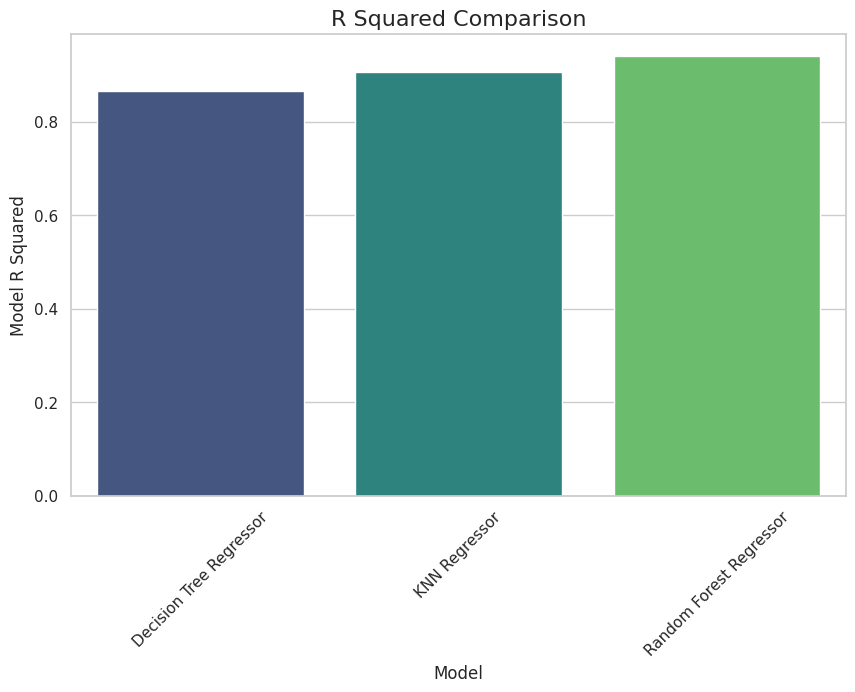

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample accuracy data for different models
model_names = [ 'Decision Tree Regressor','KNN Regressor' ,'Random Forest Regressor']
model_accuracies = [r2_dtr,r2_knn,r2_rfr]  # Replace with your actual accuracy values

# Set the theme for seaborn
sns.set_theme(style="whitegrid")

# Create a bar plot
plt.figure(figsize=(10, 6))  # Set figure size
sns.barplot(x=model_names, y=model_accuracies, palette="viridis")

# Add title and labels
plt.title("R Squared Comparison", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Model R Squared", fontsize=12)

# Rotate x labels if they are too long
plt.xticks(rotation=45)

# Display the plot
plt.show()


In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
'''
# Load your dataset
data = pd.read_csv("your_data.csv")

# Split the data into features and target variable
X = data.drop("target_column", axis=1)
y = data["target_column"]
'''
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Define the hyperparameter grid to explore
param_grid = {
    "fit_intercept": [True, False],
    "copy_X": [True, False]
}

# Create a linear regression model
lr = LinearRegression()

# Create a GridSearchCV object
grid_search = GridSearchCV(lr, param_grid, cv=5, scoring="r2")

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

# Create a new linear regression model with the best parameters
best_lr = LinearRegression(**best_params)

# Fit the best linear regression model to the training data
best_lr.fit(X_train, y_train)
y_pred_lr  = best_lr.predict(X_test)
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred_lr)
r2


Best Parameters: {'copy_X': True, 'fit_intercept': True}
Best Score: 0.8879742522131364


0.9059011844150826

In [48]:
best_lr.predict([[100,100,200],[500,200,10]])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([21.12691909, 52.20120077])

In [49]:
best_lr.predict(np.array([100,100,200]).reshape(1,3))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([21.12691909])

**Cross Validation**

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


# Load your dataset
data = pd.read_csv("/content/advertising.csv")

# Split the data into features and target variable
X = data.iloc[:,:-1]
y = data.iloc[:,-1]

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
 random_state=42)

# Create a linear regression model
model = LinearRegression()

# Perform k-fold cross-validation
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print(scores)
# Calculate the mean and standard deviation of the scores
mean_score = scores.mean()

std_score = scores.std()

print("Mean Squared Error:", -mean_score)
print("Standard Deviation:", std_score)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_pred

[-2.38336184 -2.55206051 -2.8082948  -2.10335558 -3.85387808]
Mean Squared Error: 2.740190162571438
Standard Deviation: 0.6021987237464433


array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

In [51]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_pred

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

The reason scoring='neg_mean_squared_error' is used instead of scoring='mean_squared_error' in cross-validation is to ensure that the optimization process maximizes the score.

In many machine learning algorithms, the goal is to minimize a loss function. The mean squared error (MSE) is a common loss function used for regression problems. However, when using cross-validation, the cross_val_score function aims to maximize the score.

By using scoring='neg_mean_squared_error', we effectively negate the MSE, transforming it into a maximization problem. This means that the algorithm will strive to minimize the MSE, which is the desired behavior in regression tasks.

To summarize:

MSE is a minimization problem: We want to minimize the difference between predicted and actual values.
Cross-validation maximizes scores: The cross_val_score function is designed to maximize the score.
Negating MSE converts it to a maximization problem: By negating the MSE, we align it with the maximization goal of cross-validation.
Therefore, using scoring='neg_mean_squared_error' ensures that the cross-validation process correctly optimizes the model for regression tasks.

In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


# Load your dataset
data = pd.read_csv("/content/advertising.csv")

# Split the data into features and target variable
X = data.iloc[:,:-1]
y = data.iloc[:,-1]

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
 random_state=42)

# Create a linear regression model
model = LinearRegression()

# Perform k-fold cross-validation
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

# Calculate the mean and standard deviation of the scores
mean_score = scores.mean()

std_score = scores.std()

print("R2 Squared Error:",mean_score )
print("Standard Deviation:", std_score)

R2 Squared Error: 0.8879742522131364
Standard Deviation: 0.021070307801382877


In [54]:
#now fit model
model.fit(X_train,y_train)


LinearRegression()

In [55]:
y_pred_cross_val = model.predict(X_test)
y_pred_cross_val

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

In [56]:
from sklearn.metrics import mean_squared_error ,r2_score
r2 = r2_score(y_test,y_pred_cross_val)
r2

0.9059011844150826

**K Fold Cross Validation**

In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score,KFold


# Load your dataset
data = pd.read_csv("/content/advertising.csv")

# Split the data into features and target variable
X = data.iloc[:,:-1]
y = data.iloc[:,-1]

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
 random_state=42)

# Create a linear regression model
model = LinearRegression()

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
# Perform k-fold cross-validation
scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')

# Calculate the mean and standard deviation of the scores
mean_score = scores.mean()

std_score = scores.std()

print("R2 Squared Error:",mean_score )
print("Standard Deviation:", std_score)

#now fit model
model.fit(X_train,y_train)

#predict
y_pred_k_fold_ross_val = model.predict(X_test)
y_pred_k_fold_ross_val

R2 Squared Error: 0.8792707526938137
Standard Deviation: 0.05525411438551655


array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

In [58]:
from sklearn.metrics import mean_squared_error ,r2_score
r2 = r2_score(y_test,y_pred_k_fold_ross_val)
r2

0.9059011844150826

In [59]:
from sklearn.metrics._scorer import _SCORERS
_SCORERS.keys()

dict_keys(['explained_variance', 'r2', 'max_error', 'matthews_corrcoef', 'neg_median_absolute_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'neg_mean_poisson_deviance', 'neg_mean_gamma_deviance', 'd2_absolute_error_score', 'accuracy', 'top_k_accuracy', 'roc_auc', 'roc_auc_ovr', 'roc_auc_ovo', 'roc_auc_ovr_weighted', 'roc_auc_ovo_weighted', 'balanced_accuracy', 'average_precision', 'neg_log_loss', 'neg_brier_score', 'positive_likelihood_ratio', 'neg_negative_likelihood_ratio', 'adjusted_rand_score', 'rand_score', 'homogeneity_score', 'completeness_score', 'v_measure_score', 'mutual_info_score', 'adjusted_mutual_info_score', 'normalized_mutual_info_score', 'fowlkes_mallows_score', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'recall', 'recall_macro', 'recall_micro', 'recall_samples', 'recall_w